# 用邻接表实现图

In [86]:
from matplotlib.pyplot import disconnect
from pydantic_core.core_schema import plain_serializer_function_ser_schema


class Graph:
    def __init__(self, is_directed=False):
        self.is_directed = is_directed # 是否为有向图
        self.adj_list={} # 邻接表:{顶点:[邻接顶点1,邻接顶点2,邻接顶点3,...]}

    def add_vertex(self, vertex):
        """添加顶点（若不存在则初始化）"""
        if vertex not in self.adj_list:
            self.adj_list[vertex]=[]

    def add_edge(self, vertex1, vertex2):
        """添加边：v1 -> v2"""
        # 确保两个顶点都存在
        self.add_vertex(vertex1)
        self.add_vertex(vertex2)

        # 向vertex1的邻接表添加vertex2
        if vertex2 not in self.adj_list[vertex1]:
            self.adj_list[vertex1].append(vertex2)

        # 无向图：反向边也添加
        if not self.is_directed and vertex1 not in self.adj_list[vertex2]:
            self.adj_list[vertex2].append(vertex1)

        def remove_edge(self, vertex1, vertex2):
            """删除边：v1 -> v2（无向图同时删除v2 -> v1）"""
            if vertex1 in self.adj_list and vertex2 in self.adj_list[vertex1]:
                self.adj_list[vertex1].remove(vertex2)
            if not self.is_directed and vertex2 in self.adj_list and vertex1 in self.adj_list[vertex2]:
                self.adj_list[vertex2].remove(vertex1)

    def remove_vertex(self, vertex):
        """删除顶点（同时删除所有关联的边）"""
        if vertex not in self.adj_list:
            return
        # 1. 删除其他顶点的邻接表
        del self.adj_list[vertex]
        # 2. 删除其他顶点中指向改顶点的边
        for v in self.adj_list:
            if vertex in self.adj_list[v]:
                self.adj_list[v].remove(vertex)

    def __str__(self):
        """打印邻接表"""
        result = []
        for vertex in self.adj_list:
            result.append(f'{vertex}: {self.adj_list[vertex]}')
        return '\n'.join(result)

## 无向图
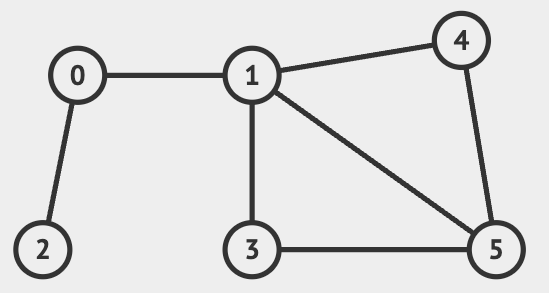

In [87]:
undirected_graph = Graph(is_directed=False)
undirected_graph.add_edge("0", "1")
undirected_graph.add_edge("0", "2")
undirected_graph.add_edge("1", "3")
undirected_graph.add_edge("1", "4")
undirected_graph.add_edge("1", "5")
undirected_graph.add_edge("3", "5")
undirected_graph.add_edge("4", "5")

print(undirected_graph)

0: ['1', '2']
1: ['0', '3', '4', '5']
2: ['0']
3: ['1', '5']
4: ['1', '5']
5: ['1', '3', '4']


## 有向图
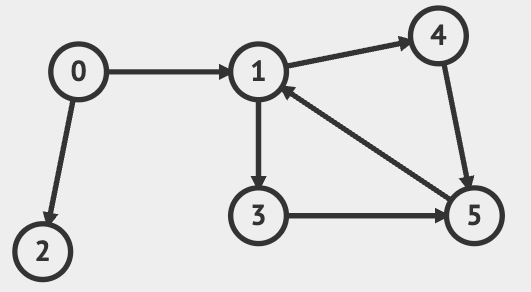

In [88]:
directed_graph = Graph(is_directed=True)
directed_graph.add_edge("0", "1")
directed_graph.add_edge("0", "2")
directed_graph.add_edge("1", "3")
directed_graph.add_edge("1", "4")
directed_graph.add_edge("3", "5")
directed_graph.add_edge("4", "5")
directed_graph.add_edge("5", "1")

print(directed_graph)

0: ['1', '2']
1: ['3', '4']
2: []
3: ['5']
4: ['5']
5: ['1']


## 深度优先遍历｜DFS
- 先深后广，从起始顶点出发，优先访问邻接的未访问顶点，直到无法深入再回溯
- 实现方式：递归+迭代

In [89]:
class DFS:
    def __init__(self, graph):
        self.graph = graph

    def dfs_recursive(self, satrt_vertex, visited=None):
        """DFS递归版"""
        if visited is None: # 初始化已访问集合，避免重复访问，解决环的问题
            visited = set()
        visited.add(satrt_vertex) # 标记当前顶点已访问
        result = [satrt_vertex] # 存储遍历结果

        for neighbor in self.graph.adj_list[satrt_vertex]: # 遍历当前顶点的所有邻接顶点
            if neighbor not in visited:
                result.extend(self.dfs_recursive(neighbor, visited))
        return result

    def dfs_iterative(self,start_vertex):
        """DFS迭代版，用栈实现"""
        if start_vertex not in self.graph.adj_list:
            return []
        visited = set() # 记录已访问节点
        stack = [start_vertex] # 栈存储待访问顶点
        result = []

        while stack:
            vertex = stack.pop()
            if vertex not in visited:
                visited.add(vertex)
                result.append(vertex)
                # 逆序添加邻接顶点（保证遍历顺序和递归版本一致）
                for neighbor in reversed(self.graph.adj_list[vertex]):
                    if neighbor not in visited:
                        stack.append(neighbor)
        return result

In [90]:
undfs = DFS(undirected_graph)
dfs = DFS(directed_graph)

dfs.dfs_recursive("0"),dfs.dfs_iterative("0")

(['0', '1', '3', '5', '4', '2'], ['0', '1', '3', '5', '4', '2'])

## 广度优先遍历｜BFS
- 核心逻辑：先广后深，从起始顶点出发，先访问所有邻接顶点，再逐层访问下一级顶点。
- 迭代（使用队列，FIFO特性保证“广度”）

In [91]:
from collections import deque # 高效的双端队列

class BFS:
    def __init__(self, graph):
        self.graph = graph

    def bfs(self, start_vertex):
        """BFS遍历，队列实现"""
        if start_vertex not in self.graph.adj_list:
            return []
        visited = set() # 初始化已访问顶点
        queue = deque(start_vertex) # 队列存储待访问顶点
        visited.add(start_vertex)
        result = [start_vertex]
        while queue:
            vertex = queue.popleft() # 弹出队首顶点
            for neighbor in self.graph.adj_list[vertex]: # 遍历当前顶点的所有邻接顶点
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append(neighbor)
                    result.append(neighbor)
        return result

In [92]:
unbfs = BFS(undirected_graph)
bfs = BFS(directed_graph)

unbfs.bfs("0"),bfs.bfs("0")

(['0', '1', '2', '3', '4', '5'], ['0', '1', '2', '3', '4', '5'])

## 非连通图的遍历

In [102]:
def dfs_full(self):
    """遍历全图（处理非连通图）"""
    visited = set()
    result = []
    for vertex in self.graph.adj_list:
        if vertex not in visited:
            result += self.dfs_recursive(vertex, visited)
    return result

def bfs_full(self):
    """遍历全图（处理非连通图）"""
    visited = set()
    result = []
    for vertex in self.graph.adj_list:
        if vertex not in visited:
            # 单独处理当前连通分量的BFS
            queue = deque([vertex])
            visited.add(vertex)
            result.append(vertex)
            while queue:
                v = queue.popleft()
                for neighbor in self.graph.adj_list[v]:
                    if neighbor not in visited:
                        visited.add(neighbor)
                        queue.append(neighbor)
                        result.append(neighbor)
    return result

# 让上面两个方法绑定进上上面的两个类里面
DFS.dfs_full = dfs_full
BFS.bfs_full = bfs_full

In [103]:
undirected_graph.add_edge("6", "7")
directed_graph.add_edge("6", "7")

undfs.dfs_full(),dfs.dfs_full(),unbfs.bfs_full(),bfs.bfs_full()

(['0', '1', '3', '5', '4', '2', '6', '7'],
 ['0', '1', '3', '5', '4', '2', '6', '7'],
 ['0', '1', '2', '3', '4', '5', '6', '7'],
 ['0', '1', '2', '3', '4', '5', '6', '7'])

# 带权重图

In [104]:
class WeightedGraph:
    """带权图：支持有向/无向"""
    def __init__(self, is_directed=False):
        self.adj_list = {} # 邻接表
        self.vertices = [] # 存储所有顶点（方便Floyd算法）
        self.is_directed = is_directed
    def add_vertex(self,vertex):
        """添加顶点"""
        if vertex not in self.adj_list:
            self.adj_list[vertex] = []
            self.vertices.append(vertex)

    def add_edge(self,v1,v2,weight):
        """添加边"""
        self.add_vertex(v1)
        self.add_vertex(v2)
        # 避免重复边添加
        for (neighbor,w) in self.adj_list[v1]:
            if neighbor == v2:
                return
        self.adj_list[v1].append((v2,weight))
        if not self.is_directed:
            for (neighbor,w) in self.adj_list[v2]:
                if neighbor == v1:
                    return
            self.adj_list[v2].append((v1,weight))

    def __str__(self):
        result = []
        for vertex in self.adj_list:
            edges = [f"({v}, {w})" for v, w in self.adj_list[vertex]]
            result.append(f"{vertex}: {edges}")
        return "\n".join(result)

In [105]:
wg = WeightedGraph(is_directed=False)
wg.add_edge("A", "B", 2)
wg.add_edge("A", "C", 1)
wg.add_edge("B", "D", 3)
wg.add_edge("B", "E", 5)
wg.add_edge("C", "D", 1)
wg.add_edge("D", "E", 2)
print(wg)

A: ['(B, 2)', '(C, 1)']
B: ['(A, 2)', '(D, 3)', '(E, 5)']
C: ['(A, 1)', '(D, 1)']
D: ['(B, 3)', '(C, 1)', '(E, 2)']
E: ['(B, 5)', '(D, 2)']


# 最小生成树
## Prim算法
- **基于顶点的贪心算法**，核心逻辑是：逐步扩展连通分量。
1. 初始化：任选一个顶点作为起点，加入**已选顶点集合$S$**，剩余顶点为**未选顶点集合$T$**
2. 贪心选边：每一轮选择连接$S$和$T$的权值最小的边，将边的$T$侧顶点加入$S$，同时将边加入MST
3. 终止条件：$S$包含所有顶点时停止，选中的边天然无环，构成完成MST

In [111]:
def prim_naive(self,start_vertex=None):
    """
    朴素prim算法（邻接矩阵实现）。时间复杂度O(V^2)，适合稠密图
    :param self:
    :param start_vertex:
    :return:
    """
    if not self.vertices:
        return [],0
    # 初始化起点,默认选第一个顶点
    start_vertex = start_vertex if start_vertex else self.vertices[0]
    n = len(self.vertices)
    # 顶点与索引的双向映射
    v2i = {v: i for i, v in enumerate(self.vertices)}
    i2v = {i: v for i, v in enumerate(self.vertices)}
    INF = float('inf')

    # 1. 构建邻接矩阵
    adj_matrix = [[INF] * n for _ in range(n)]
    for u in self.adj_list:
        u_idx = v2i[u]
        for v, w in self.adj_list[u]:
            v_idx = v2i[v]
            adj_matrix[u_idx][v_idx] = w
            adj_matrix[v_idx][u_idx] = w  # 无向图双向赋值

    # 2. 初始化核心数组
    key = [INF] * n       # 顶点到已选集合的最小边权
    parent = [-1] * n      # 记录MST的前驱顶点
    in_mst = [False] * n   # 标记是否已加入MST
    key[v2i[start_vertex]] = 0  # 起点初始权值为0

    mst_edges = []
    total_weight = 0

    # 3. 遍历所有顶点
    for _ in range(n):
        # 选key最小的、未加入MST的顶点
        min_key = INF
        u_idx = -1
        for i in range(n):
            if not in_mst[i] and key[i] < min_key:
                min_key = key[i]
                u_idx = i
        if u_idx == -1:
            break  # 非连通图，无法生成完整MST

        # 加入MST
        in_mst[u_idx] = True
        total_weight += min_key
        if parent[u_idx] != -1:
            mst_edges.append((i2v[parent[u_idx]], i2v[u_idx], min_key))

        # 更新邻接顶点的key值
        for v_idx in range(n):
            if not in_mst[v_idx] and adj_matrix[u_idx][v_idx] < key[v_idx]:
                key[v_idx] = adj_matrix[u_idx][v_idx]
                parent[v_idx] = u_idx

    return mst_edges, total_weight

In [112]:
import heapq


# 堆优化Prim算法（邻接表实现）
def prim_heap(self, start_vertex=None):
    """
    堆优化Prim算法：时间复杂度O(ElogV)，适合稀疏图
    返回：MST边列表、总权值
    """
    if not self.vertices:
        return [], 0
    start_vertex = start_vertex if start_vertex else self.vertices[0]

    # 初始化核心结构
    key = {v: float('inf') for v in self.vertices}
    key[start_vertex] = 0
    parent = {v: None for v in self.vertices}
    in_mst = set()
    mst_edges = []
    total_weight = 0

    # 最小堆：(顶点到已选集合的最小权值, 顶点)
    heap = []
    heapq.heappush(heap, (0, start_vertex))

    while heap:
        current_key, u = heapq.heappop(heap)
        if u in in_mst:
            continue  # 跳过堆中已加入MST的旧数据

        # 加入MST
        in_mst.add(u)
        total_weight += current_key
        if parent[u] is not None:
            mst_edges.append((parent[u], u, current_key))

        # 更新邻接顶点的key值
        for v, weight in self.adj_list[u]:
            if v not in in_mst and weight < key[v]:
                key[v] = weight
                parent[v] = u
                heapq.heappush(heap, (weight, v))

    return mst_edges, total_weight

In [113]:
# 绑定到之前的WeightedGraph类
WeightedGraph.prim_naive = prim_naive
WeightedGraph.prim_heap = prim_heap

In [114]:
print("=== 朴素Prim算法测试 ===")
naive_edges, naive_total = wg.prim_naive("A")
print("MST边：", naive_edges)  # 输出：[('A','C',1), ('C','D',1), ('D','E',2), ('A','B',2)]
print("总权值：", naive_total) # 输出：6

print("\n=== 堆优化Prim算法测试 ===")
heap_edges, heap_total = wg.prim_heap("A")
print("MST边：", heap_edges)  # 输出与朴素版一致
print("总权值：", heap_total) # 输出：6

=== 朴素Prim算法测试 ===
MST边： [('A', 'C', 1), ('C', 'D', 1), ('A', 'B', 2), ('D', 'E', 2)]
总权值： 6

=== 堆优化Prim算法测试 ===
MST边： [('A', 'C', 1), ('C', 'D', 1), ('A', 'B', 2), ('D', 'E', 2)]
总权值： 6


## Kruskal算法
- 贪心策略：将所有边**按权值从小到大排序**，依次选边，若选的边连接两个不同的连通分量（用**并查集**判断），则加入MST
- 连接所有顶点，总边权最小，且无环

### 并查集实现
- 并查集用于高效判断连通性、合并连通分量

In [115]:
class UnionFind:
    """并查集：路径压缩+按秩合并"""
    def __init__(self, vertices):
        self.parent = {v: v for v in vertices} # 父节点字典
        self.rank = {v: 0 for v in vertices} # 秩（优化树高）

    def find(self,x):
        """查找x的根节点（路径压缩）"""
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self,x,y):
        """合并x和y所在的连通分量"""
        x_root = self.find(x)
        y_root = self.find(y)
        if x_root == y_root:
            return False
        if self.rank[x_root] < self.rank[y_root]:
            self.parent[x_root] = y_root
        else:
            self.parent[y_root] = x_root
            if self.rank[x_root] == self.rank[y_root]:
                self.rank[x_root] += 1
        return True

- Python实现Kruskal，时间复杂度$O(ElogE)$

In [116]:
def kruskal(self):
    """
    Kruskal算法：最小生成树（MST）
    返回：MST的边列表，总权值
    """
    # 1. 收集所有边（无向图去重，只存v1<v2的边）
    edges = []
    seen = set()
    for u in self.adj_list:
        for v, w in self.adj_list[u]:
            if (u, v) not in seen and (v, u) not in seen:
                edges.append((w, u, v))
                seen.add((u, v))

    # 2. 按边权升序排序
    edges.sort()

    # 3. 初始化并查集，选边加入MST
    uf = UnionFind(self.vertices)
    mst = []
    total_weight = 0
    for w, u, v in edges:
        if uf.union(u, v):
            mst.append((u, v, w))
            total_weight += w
            if len(mst) == len(self.vertices) - 1:
                break  # 选够n-1条边则停止

    return mst, total_weight

In [117]:
# 绑定方法
WeightedGraph.kruskal = kruskal

In [118]:
# 测试Kruskal
print("\n=== Kruskal算法测试（最小生成树） ===")
mst_edges, mst_total = wg.kruskal()
print("MST的边:", mst_edges)  # 输出: [('A','C',1), ('C','D',1), ('A','B',2), ('D','E',2)]
print("MST总权值:", mst_total)  # 输出: 6


=== Kruskal算法测试（最小生成树） ===
MST的边: [('A', 'C', 1), ('C', 'D', 1), ('A', 'B', 2), ('D', 'E', 2)]
MST总权值: 6


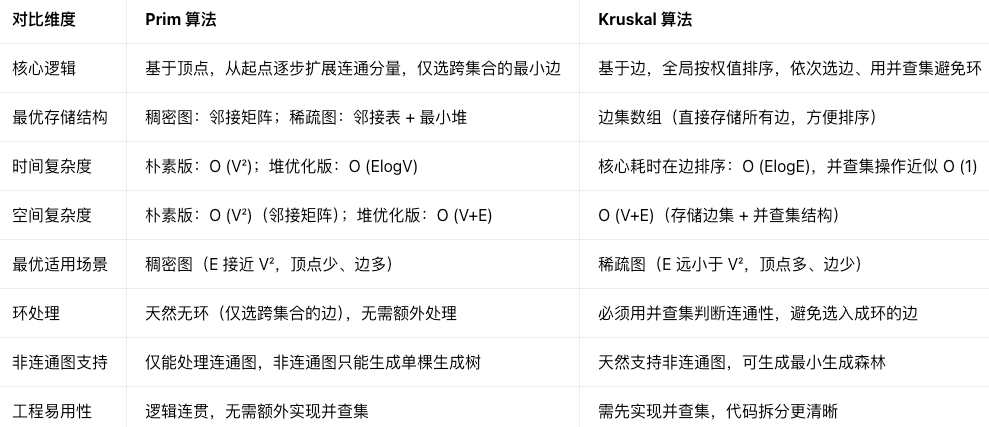